In [1]:
# Cell 1: Kaggle setup and download
from google.colab import files
files.upload()  # upload your kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d heitornunes/mechanical-analysis
!unzip -o mechanical-analysis.zip
!ls *.csv

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/heitornunes/mechanical-analysis
License(s): copyright-authors
100% 118k/118k [00:00<00:00, 66.8MB/s]

Archive:  mechanical-analysis.zip
  inflating: description.txt         
  inflating: mechanical-analysis.data  
  inflating: mechanical_analysis.csv  
mechanical_analysis.csv


In [2]:
# Cell 2: EDA
import pandas as pd
import numpy as np

df = pd.read_csv('mechanical_analysis.csv')
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.isnull().sum())
print(df.iloc[:, -1].value_counts())

(9254, 11)
instance         int64
number           int64
sup              int64
cpm              int64
mis            float64
misr           float64
dir             object
omega          float64
class            int64
comb. class    float64
other class    float64
dtype: object
   instance  number  sup  cpm    mis  misr dir   omega  class  comb. class  \
0         1       0    3    0  120.0  21.0  ao  1000.0      1          7.0   
1         1       1    3    0   55.0   7.5  aa  1000.0      1          7.0   
2         1       2    3    0   26.0   1.4  vo  1000.0      1          7.0   
3         1       3    3    0   11.0   0.8  va  1000.0      1          7.0   
4         1       4    2    0    7.0   5.5  ao  1000.0      1          7.0   

   other class  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  
instance          0
number            0
sup               0
cpm               0
mis               0
misr              0
dir               0
omega      

In [3]:
# Cell 3: Aggregate per machine instance
# dir encodes measurement type (ao/aa/vo/va) — pivot into columns
df_pivot = df.pivot_table(index='instance', columns='dir',
                          values=['mis','misr'], aggfunc='mean')
df_pivot.columns = ['_'.join(c) for c in df_pivot.columns]
df_pivot.reset_index(inplace=True)

# attach machine-level features (constant per instance)
meta = df.groupby('instance').agg(
    sup=('sup','first'),
    cpm=('cpm','first'),
    omega=('omega','first'),
    label=('class','first')
).reset_index()

data = df_pivot.merge(meta, on='instance')
print(data.shape)
print(data.dtypes)
print(data['label'].value_counts())

(209, 25)
instance      int64
mis_aa      float64
mis_ao      float64
mis_av      float64
mis_ia      float64
mis_io      float64
mis_iv      float64
mis_ma      float64
mis_va      float64
mis_vo      float64
mis_vv      float64
misr_aa     float64
misr_ao     float64
misr_av     float64
misr_ia     float64
misr_io     float64
misr_iv     float64
misr_ma     float64
misr_va     float64
misr_vo     float64
misr_vv     float64
sup           int64
cpm           int64
omega       float64
label         int64
dtype: object
label
2    69
1    63
6    28
4    18
5    17
3    14
Name: count, dtype: int64


(209, 24)
0


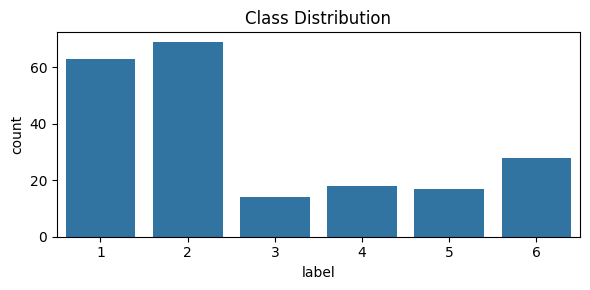

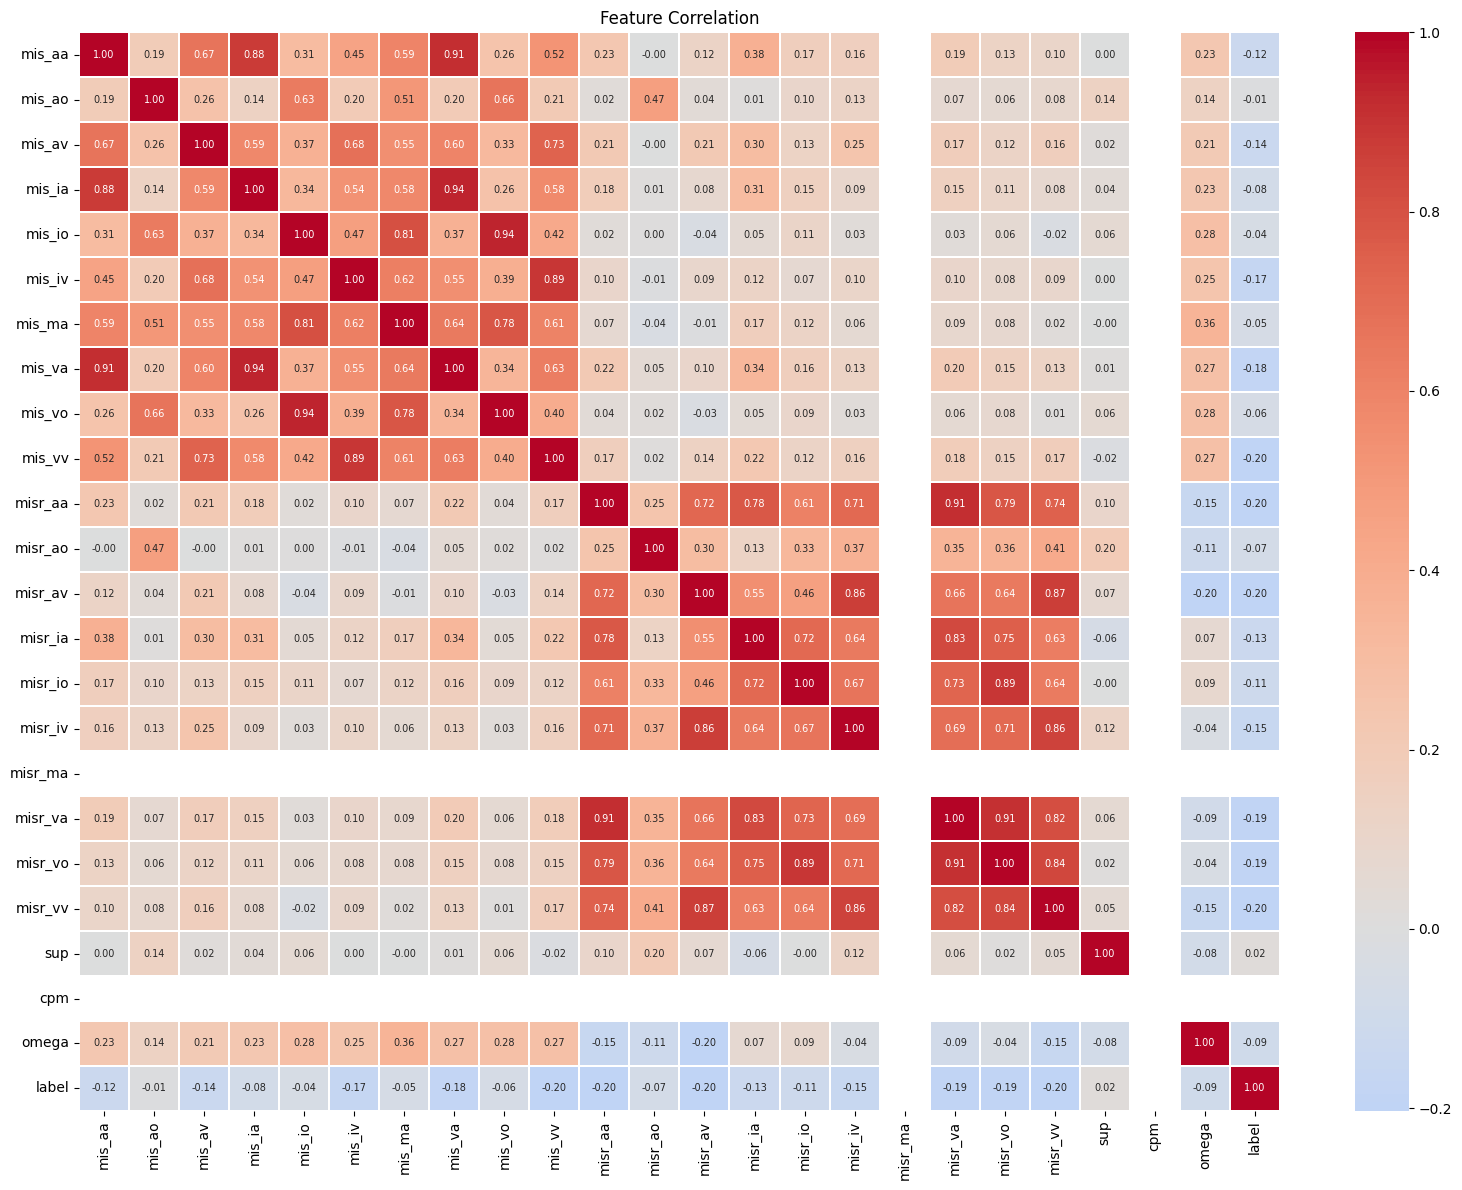

In [5]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

data.drop(columns=['instance'], inplace=True, errors='ignore')
data.dropna(thresh=len(data)*0.5, axis=1, inplace=True)
data.fillna(data.median(numeric_only=True), inplace=True)

print(data.shape)
print(data.isnull().sum().sum())

plt.figure(figsize=(6,3))
sns.countplot(x='label', data=data)
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16,12))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.3, annot_kws={'size':7})
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

X = data.drop(columns=['label'])
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

sel = VarianceThreshold(threshold=0.0)
X_train_sc = sel.fit_transform(X_train_sc)
X_test_sc  = sel.transform(X_test_sc)
feature_names = X_train.columns[sel.get_support()].tolist()

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

models = {
    'Logistic Regression': GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}, cv=5, scoring='accuracy'),
    'Decision Tree': GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3,5,7,None], 'min_samples_split': [2,5,10]}, cv=5, scoring='accuracy'),
    'Random Forest': GridSearchCV(
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100,200], 'max_depth': [5,10,None]}, cv=5, scoring='accuracy'),
    'Gradient Boosting': GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100,200], 'max_depth': [3,5], 'learning_rate': [0.05,0.1]}, cv=5, scoring='accuracy'),
    'XGBoost': GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='mlogloss'),
        {'n_estimators': [100,200], 'max_depth': [3,5], 'learning_rate': [0.05,0.1]}, cv=5, scoring='accuracy'),
}

results = {}
for name, m in models.items():
    m.fit(X_train_sc, y_train_enc)
    preds = m.predict(X_test_sc)
    acc = accuracy_score(y_test_enc, preds)
    results[name] = acc
    print(f'{name}: {acc:.4f} | best: {m.best_params_}')

Logistic Regression: 0.7381 | best: {'C': 1}
Decision Tree: 0.6667 | best: {'max_depth': 5, 'min_samples_split': 2}
Random Forest: 0.6905 | best: {'max_depth': None, 'n_estimators': 200}
Gradient Boosting: 0.6905 | best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost: 0.6905 | best: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


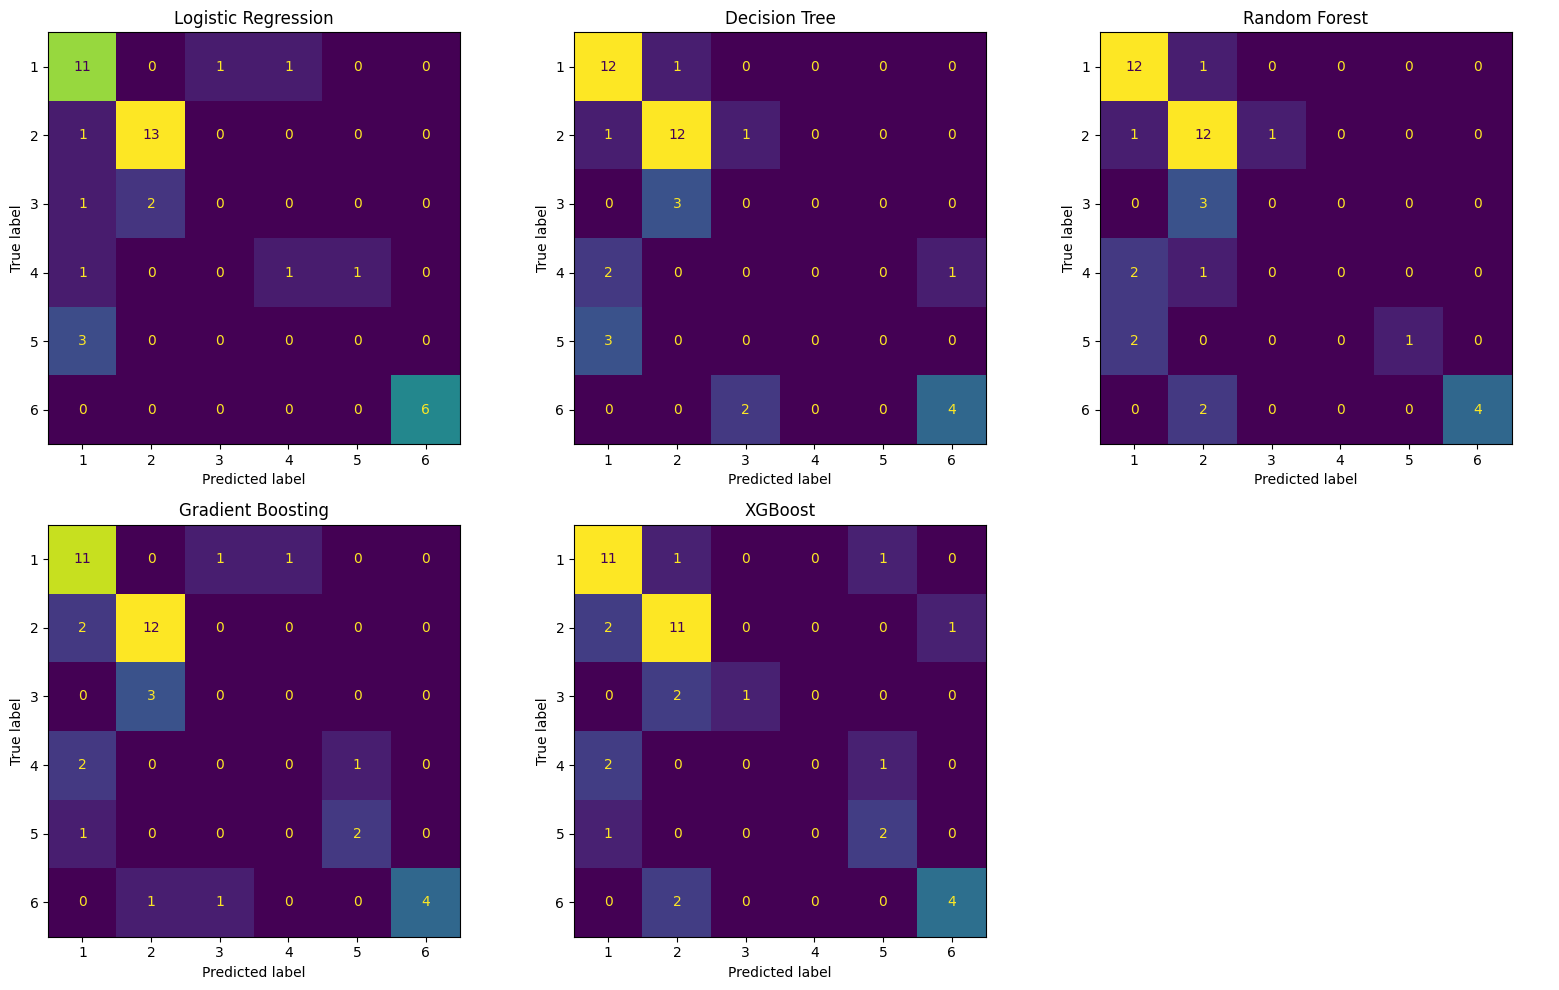

              precision    recall  f1-score   support

     class 1       0.65      0.85      0.73        13
     class 2       0.87      0.93      0.90        14
     class 3       0.00      0.00      0.00         3
     class 4       0.50      0.33      0.40         3
     class 5       0.00      0.00      0.00         3
     class 6       1.00      1.00      1.00         6

    accuracy                           0.74        42
   macro avg       0.50      0.52      0.50        42
weighted avg       0.67      0.74      0.70        42



In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (name, m) in enumerate(models.items()):
    preds = m.predict(X_test_sc)
    cm = confusion_matrix(y_test_enc, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

print(classification_report(y_test_enc, models['Logistic Regression'].predict(X_test_sc),
                            target_names=[f'class {c}' for c in le.classes_]))

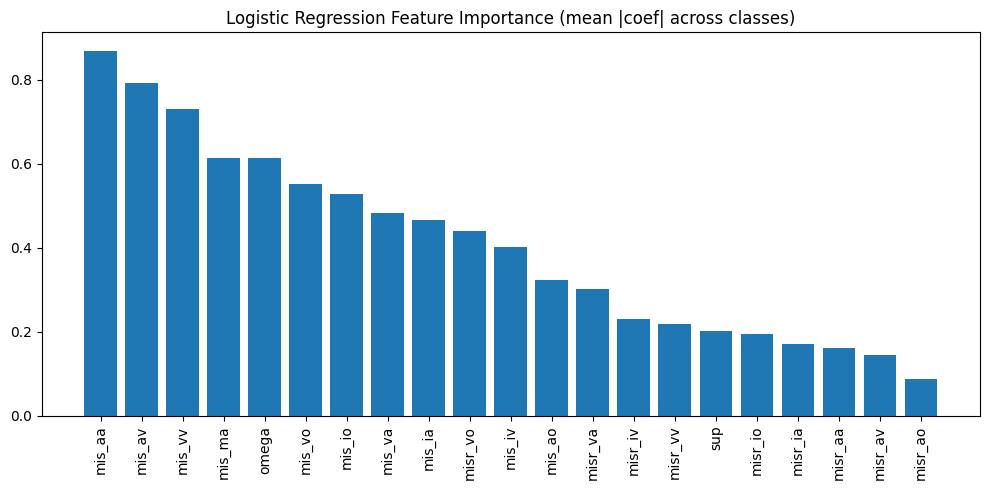

In [18]:
import matplotlib.pyplot as plt
import numpy as np

coef = np.abs(models['Logistic Regression'].best_estimator_.coef_)
importance = coef.mean(axis=0)
idx = np.argsort(importance)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(feature_names)), importance[idx])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in idx], rotation=90)
plt.title('Logistic Regression Feature Importance (mean |coef| across classes)')
plt.tight_layout()
plt.show()

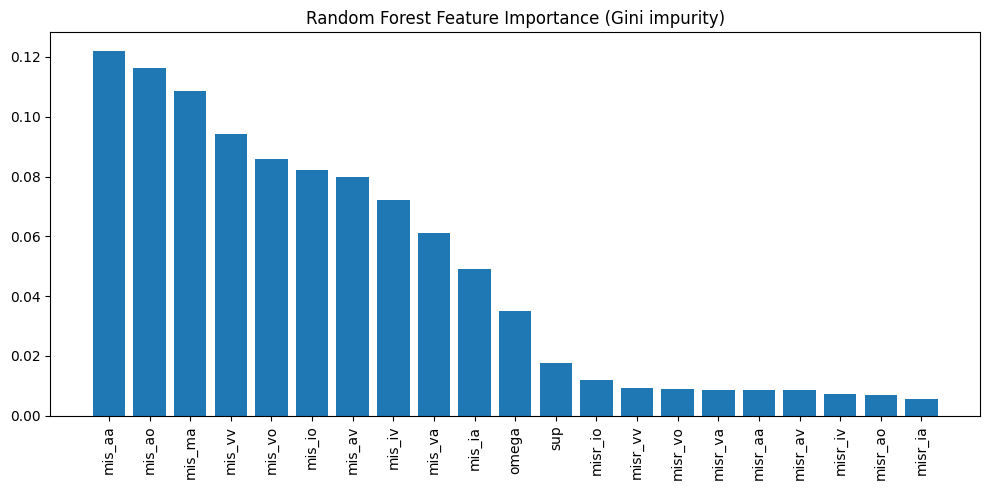

In [19]:
rf_importance = models['Random Forest'].best_estimator_.feature_importances_
idx = np.argsort(rf_importance)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(feature_names)), rf_importance[idx])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in idx], rotation=90)
plt.title('Random Forest Feature Importance (Gini impurity)')
plt.tight_layout()
plt.show()

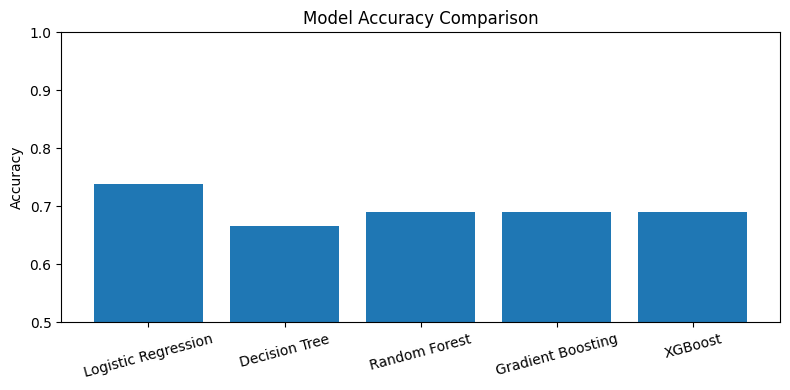

In [20]:
plt.figure(figsize=(8,4))
plt.bar(results.keys(), results.values())
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [21]:
interpretation = {
    'mis_aa': 'Absolute vibration amplitude, axial direction, acceleration — primary indicator of axial imbalance and misalignment faults',
    'mis_av': 'Absolute vibration amplitude, axial direction, velocity — corroborates axial fault severity at mid-frequency range',
    'mis_vv': 'Absolute vibration amplitude, vertical direction, velocity — key indicator of rotor unbalance and bearing wear',
    'mis_ma': 'Absolute vibration amplitude, motor axial, acceleration — detects motor-side mechanical looseness',
    'omega':  'Rotational speed (RPM) — fault signatures shift with speed; essential for normalizing vibration severity',
    'mis_vo': 'Absolute vibration amplitude, vertical direction, displacement — low-frequency structural resonance indicator',
    'mis_io': 'Absolute vibration amplitude, inner race, displacement — direct bearing inner race fault indicator',
}

print("Top Feature Mechanical Interpretation\n" + "="*50)
for feat, desc in interpretation.items():
    print(f'\n{feat}:\n  {desc}')

Top Feature Mechanical Interpretation

mis_aa:
  Absolute vibration amplitude, axial direction, acceleration — primary indicator of axial imbalance and misalignment faults

mis_av:
  Absolute vibration amplitude, axial direction, velocity — corroborates axial fault severity at mid-frequency range

mis_vv:
  Absolute vibration amplitude, vertical direction, velocity — key indicator of rotor unbalance and bearing wear

mis_ma:
  Absolute vibration amplitude, motor axial, acceleration — detects motor-side mechanical looseness

omega:
  Rotational speed (RPM) — fault signatures shift with speed; essential for normalizing vibration severity

mis_vo:
  Absolute vibration amplitude, vertical direction, displacement — low-frequency structural resonance indicator

mis_io:
  Absolute vibration amplitude, inner race, displacement — direct bearing inner race fault indicator


In [22]:
import pandas as pd

summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [round(v, 4) for v in results.values()],
    'Best Params': [models[k].best_params_ for k in results.keys()]
})
summary = summary.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model  Accuracy                                                  Best Params
Logistic Regression    0.7381                                                     {'C': 1}
      Random Forest    0.6905                     {'max_depth': None, 'n_estimators': 200}
  Gradient Boosting    0.6905 {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
            XGBoost    0.6905 {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
      Decision Tree    0.6667                     {'max_depth': 5, 'min_samples_split': 2}
